# Model Evaluation
**Group J - Diabetes Prediction Project**

This notebook evaluates the trained model on both imbalanced (original) and balanced test sets.

## Part 0. Import Libraries

In [38]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)


plt.style.use('ggplot')

## Part 1. Evaluation Function

In [42]:
# Load metadata
meta_data = joblib.load('../models/meta.pkl')

# Extract the best threshold
best_threshold = meta_data['threshold']['best_threshold']

print(f"Optimal Threshold loaded from training: {best_threshold}")

Optimal Threshold loaded from training: 0.42000000000000004


In [43]:
def evaluate_model(model_path, test_data, threshold=best_threshold):
    """
    Evaluate model with a specific classification threshold.
    """
    pipeline = joblib.load(model_path)
    
    y_true = test_data["Outcome"].astype(int)
    X = test_data.drop(columns=["Outcome", "subject_id"], errors="ignore")
    
    # 1. Get Probabilities (Confidence scores)
    y_proba = pipeline.predict_proba(X)[:, 1]
    
    # 2. Apply the custom threshold manually
    # If probability >= threshold, predict 1 (Diabetes), else 0
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "F1-Score": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": recall_score(y_true, y_pred, pos_label=0)
    }
    
    print(f"EVALUATION METRICS (Threshold: {threshold:.4f})")
    print("=" * 40)
    for name, value in metrics.items():
        print(f"{name:.<20} {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Diabetes", "Diabetes"]))
    
    return {"metrics": metrics, "y_true": y_true.values, "y_pred": y_pred, "y_proba": y_proba}

## Part 2. Load and Prepare Data

In [44]:
test_df_imbalanced = pd.read_csv('../data/test_split.csv')

print(f"\nImbalanced test set: {len(test_df_imbalanced)} samples")
print(test_df_imbalanced['Outcome'].value_counts())


Imbalanced test set: 106 samples
Outcome
0    71
1    35
Name: count, dtype: int64


In [45]:
# Create balanced test set (equal samples from each class)
test_diabetes = test_df_imbalanced[test_df_imbalanced['Outcome'] == 1]
test_no_diabetes = test_df_imbalanced[test_df_imbalanced['Outcome'] == 0]

# Sample equal number from majority class
n_minority = len(test_diabetes)
test_no_diabetes_sampled = test_no_diabetes.sample(n=n_minority, random_state=42)

# Combine into balanced test set
test_df_balanced = pd.concat([test_diabetes, test_no_diabetes_sampled])
test_df_balanced = test_df_balanced.sample(frac=1, random_state=42)  # Shuffle

print(f"Balanced test set: {len(test_df_balanced)} samples")
print(test_df_balanced['Outcome'].value_counts())

Balanced test set: 70 samples
Outcome
1    35
0    35
Name: count, dtype: int64


## Part 3. Evaluation on Imbalanced Test Set

In [46]:
print("=" * 50)
print("IMBALANCED TEST SET (Original Distribution)")
print("=" * 50)

results_imbalanced = evaluate_model(
    model_path='../models/pipeline.pkl',
    test_data=test_df_imbalanced
)

IMBALANCED TEST SET (Original Distribution)
EVALUATION METRICS (Threshold: 0.4200)
Accuracy............ 0.7453
ROC-AUC............. 0.8555
F1-Score............ 0.6824
Precision........... 0.5800
Recall.............. 0.8286
Specificity......... 0.7042

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.70      0.79        71
    Diabetes       0.58      0.83      0.68        35

    accuracy                           0.75       106
   macro avg       0.74      0.77      0.73       106
weighted avg       0.79      0.75      0.75       106



## Part 4. Evaluation on Balanced Test Set

In [47]:
print("=" * 50)
print("BALANCED TEST SET (Downsampled Distribution)")
print("=" * 50)

results_balanced = evaluate_model(
    model_path='../models/pipeline.pkl',
    test_data=test_df_balanced
)

BALANCED TEST SET (Downsampled Distribution)
EVALUATION METRICS (Threshold: 0.4200)
Accuracy............ 0.7714
ROC-AUC............. 0.8522
F1-Score............ 0.7838
Precision........... 0.7436
Recall.............. 0.8286
Specificity......... 0.7143

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.81      0.71      0.76        35
    Diabetes       0.74      0.83      0.78        35

    accuracy                           0.77        70
   macro avg       0.78      0.77      0.77        70
weighted avg       0.78      0.77      0.77        70



## Part 5. Comparison of Results

In [48]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': list(results_imbalanced['metrics'].keys()),
    'Imbalanced': [f"{v:.4f}" for v in results_imbalanced['metrics'].values()],
    'Balanced': [f"{v:.4f}" for v in results_balanced['metrics'].values()]
})
print("\nMETRICS COMPARISON")
print("=" * 45)
print(comparison.to_string(index=False))


METRICS COMPARISON
     Metric Imbalanced Balanced
   Accuracy     0.7453   0.7714
    ROC-AUC     0.8555   0.8522
   F1-Score     0.6824   0.7838
  Precision     0.5800   0.7436
     Recall     0.8286   0.8286
Specificity     0.7042   0.7143


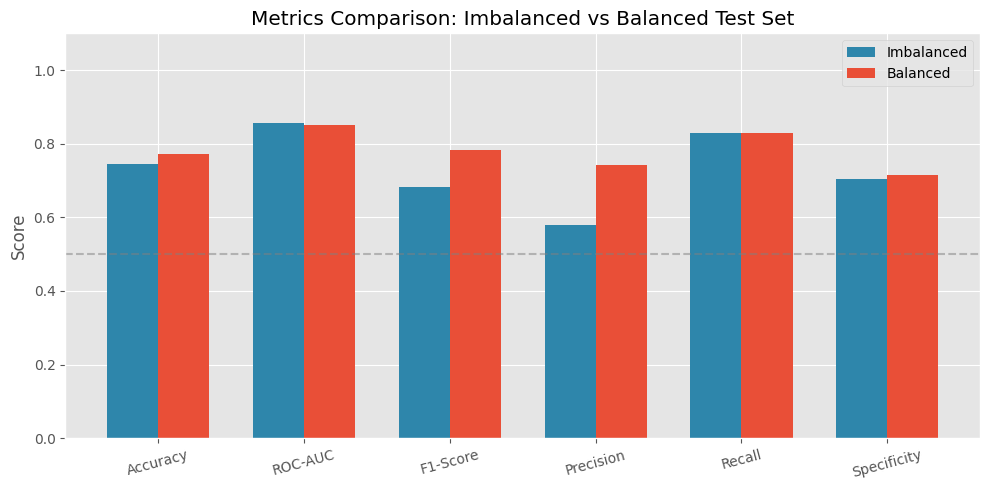

In [49]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_imbalanced['metrics']))
width = 0.35

bars1 = ax.bar(x - width/2, results_imbalanced['metrics'].values(), width, label='Imbalanced', color='#2E86AB')
bars2 = ax.bar(x + width/2, results_balanced['metrics'].values(), width, label='Balanced', color='#E94F37')

ax.set_ylabel('Score')
ax.set_title('Metrics Comparison: Imbalanced vs Balanced Test Set')
ax.set_xticks(x)
ax.set_xticklabels(results_imbalanced['metrics'].keys(), rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

## Part 6. Evaluation Plots

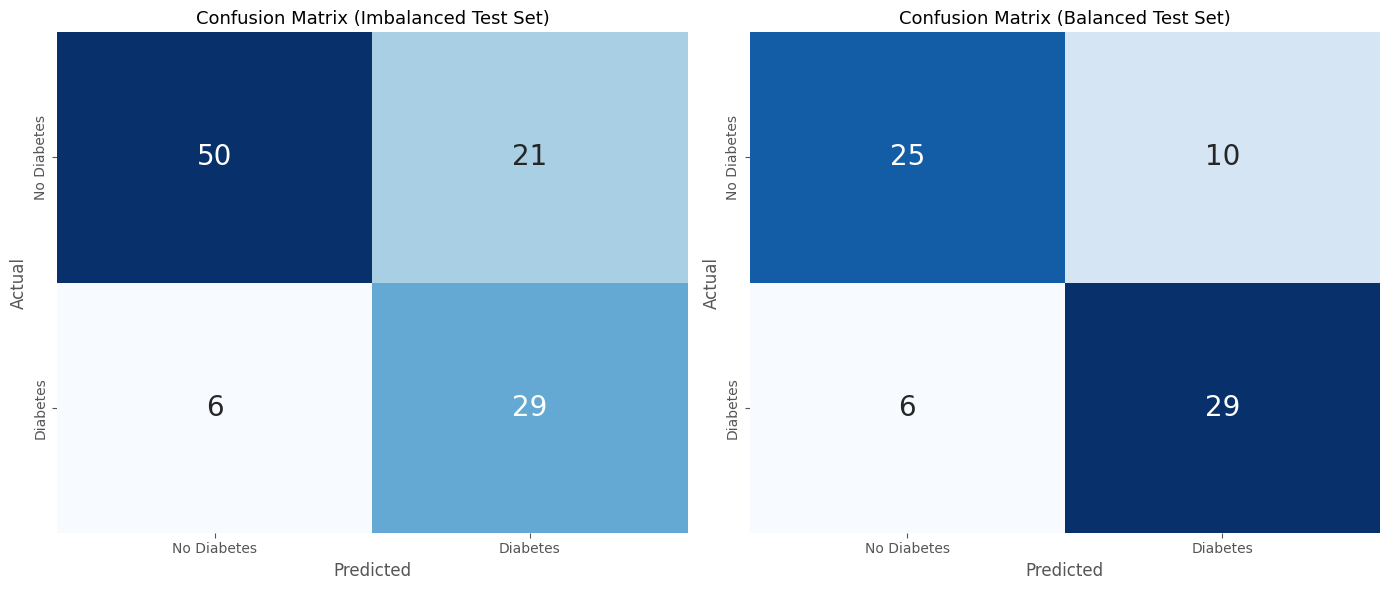

In [50]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, results, title in zip(axes, 
                               [results_imbalanced, results_balanced], 
                               ['Imbalanced Test Set', 'Balanced Test Set']):
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                annot_kws={'size': 20}, cbar=False)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix ({title})', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

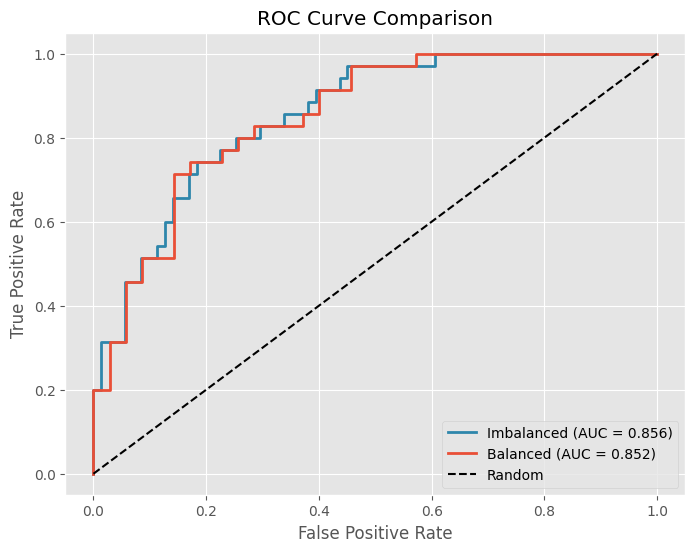

In [51]:
# ROC curves comparison
plt.figure(figsize=(8, 6))

for results, label, color in zip([results_imbalanced, results_balanced],
                                  ['Imbalanced', 'Balanced'],
                                  ['#2E86AB', '#E94F37']):
    fpr, tpr, _ = roc_curve(results['y_true'], results['y_proba'])
    auc = results['metrics']['ROC-AUC']
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

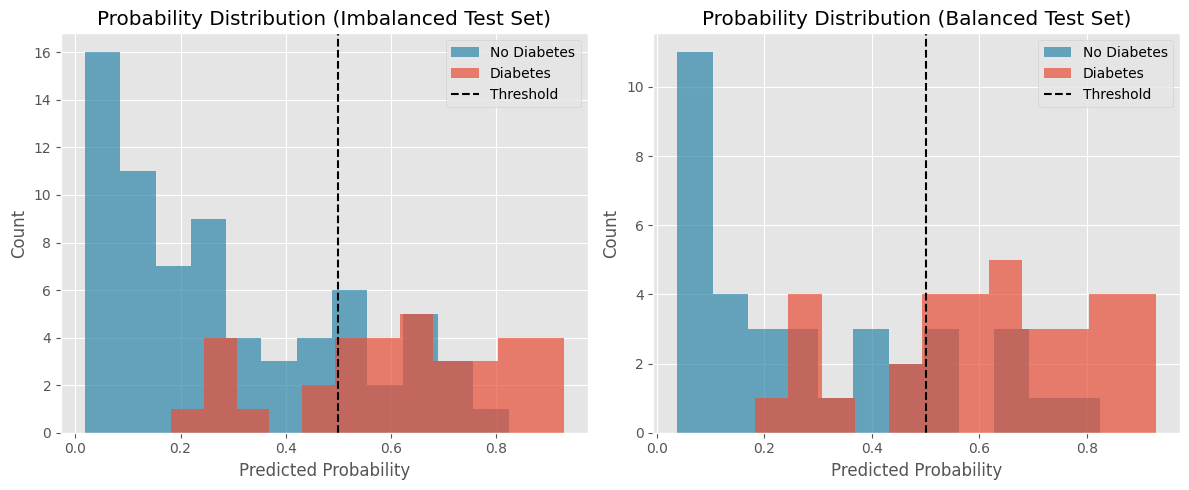

In [52]:
# Probability distributions comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, results, title in zip(axes,
                               [results_imbalanced, results_balanced],
                               ['Imbalanced Test Set', 'Balanced Test Set']):
    ax.hist(results['y_proba'][results['y_true'] == 0], bins=12, alpha=0.7, 
            label='No Diabetes', color='#2E86AB')
    ax.hist(results['y_proba'][results['y_true'] == 1], bins=12, alpha=0.7, 
            label='Diabetes', color='#E94F37')
    ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'Probability Distribution ({title})')
    ax.legend()

plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=150)
plt.show()

## Part 7. Summary

**Key Observations:**

1. **Accuracy** is higher on the imbalanced set due to the majority class bias. On the balanced set, accuracy reflects true classification ability.

2. **ROC-AUC** remains relatively stable across both settings, as it measures ranking ability independent of class distribution.

3. **Recall and Specificity** trade off differently depending on class balance - the balanced set provides clearer insight into per-class performance.

4. The **imbalanced evaluation** reflects real-world deployment performance, while the **balanced evaluation** shows the model's intrinsic ability to distinguish between classes.